# Солнечная биржа: данные и прогноз выработки

Домашняя станция продаёт энергию покупателю либо сразу, либо из аккумулятора, когда опубликованная цена выше. Нагрузки сети в данных нет: станция видит только свою выработку, погоду региона и цену выкупа.

Ноутбук делает три вещи:

1. Загружает синтетику за 2024–2025 годы: 30 станций, пять регионов Армении.
2. Показывает зимний и летний день, перенос энергии в дорогие часы и доп. доход.
3. Обучает прогноз почасовой выработки на 2024 годе и проверяет его на 2025.

## 1. Загрузка

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA = Path('data')
if not (DATA / 'stations.csv').exists():
    raise FileNotFoundError('Запустите ноутбук из корня проекта, рядом с папкой data/')

stations = pd.read_csv(DATA / 'stations.csv', encoding='utf-8-sig')
weather = pd.read_csv(DATA / 'weather_hourly.csv', encoding='utf-8-sig', parse_dates=['timestamp'])
prices = pd.read_csv(DATA / 'prices_hourly.csv', encoding='utf-8-sig', parse_dates=['timestamp'])
hourly = pd.read_csv(DATA / 'station_hourly.csv', encoding='utf-8-sig', parse_dates=['timestamp'])
daily = pd.read_csv(DATA / 'station_daily.csv', encoding='utf-8-sig', parse_dates=['date'])

plt.rcParams.update({
    'figure.figsize': (11, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})

print('Станции:', stations.shape[0])
print('Погода, строк:', len(weather))
print('Цены, часов:', len(prices))
print('Телеметрия станций:', f'{len(hourly):,}'.replace(',', ' '))
print('Период:', hourly['timestamp'].min(), '—', hourly['timestamp'].max())

Станции: 30
Погода, строк: 87720
Цены, часов: 17544
Телеметрия станций: 526 320
Период: 2024-01-01 00:00:00 — 2025-12-31 23:00:00


## 2. Станции и цена выкупа

Панель 3–10 кВт, батарея 5–15 кВт·ч. Цена одна на всю страну: обычная 25 драм/кВт·ч, повышенная вечером, зимним утром и в жаркие дневные часы. В части суток покупатель ставит 48 драм на 19:00–21:00.

,Станций,"Панель, кВт","Батарея, кВт·ч"
region_name,,,
Гегаркуник,6,7.3,9.3
Ереван,6,4.7,7.2
Лори,6,6.3,10.0
Сюник,6,6.2,10.0
Ширак,6,5.8,7.7


,station_id,region_name,pv_kw,tilt_deg,azimuth_deg,battery_kwh,battery_power_kw
0,YE-01,Ереван,5.0,35,189,8.0,4.0
1,YE-02,Ереван,3.0,35,182,10.0,3.0
2,YE-03,Ереван,5.0,27,185,5.0,2.5
3,YE-04,Ереван,5.0,37,167,5.0,2.5
4,YE-05,Ереван,5.0,25,173,10.0,5.0
5,YE-06,Ереван,5.0,28,193,5.0,2.5
6,SH-01,Ширак,5.0,33,177,5.0,2.5
7,SH-02,Ширак,5.0,27,188,8.0,4.0


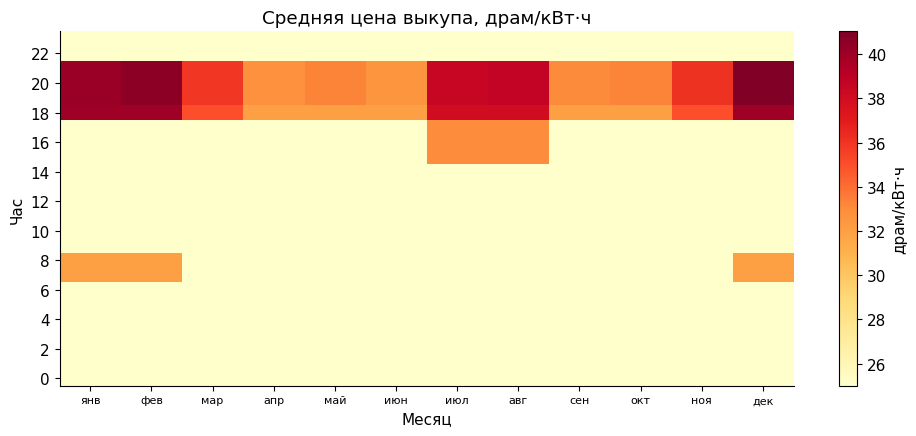

Сколько часов на каждом уровне цены:
price_amd_per_kwh
25.0    13886
32.0     1521
33.0      372
35.0      461
38.0      475
40.0      685
48.0      144


In [2]:
passport = (
    stations.groupby('region_name')
    .agg(
        stations=('station_id', 'count'),
        pv_kw=('pv_kw', 'mean'),
        battery_kwh=('battery_kwh', 'mean'),
    )
    .round(1)
)
passport.columns = ['Станций', 'Панель, кВт', 'Батарея, кВт·ч']
display(passport)

display(stations[['station_id', 'region_name', 'pv_kw', 'tilt_deg', 'azimuth_deg', 'battery_kwh', 'battery_power_kw']].head(8))

price_map = prices.copy()
price_map['hour'] = price_map['timestamp'].dt.hour
price_map['month'] = price_map['timestamp'].dt.month
heat = price_map.pivot_table(index='hour', columns='month', values='price_amd_per_kwh', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 4.5))
image = ax.imshow(heat.to_numpy(), aspect='auto', origin='lower', cmap='YlOrRd')
ax.set_xticks(range(12))
ax.set_xticklabels(['янв', 'фев', 'мар', 'апр', 'май', 'июн', 'июл', 'авг', 'сен', 'окт', 'ноя', 'дек'], fontsize=8)
ax.set_yticks(range(0, 24, 2))
ax.grid(False)
ax.set_ylabel('Час')
ax.set_xlabel('Месяц')
ax.set_title('Средняя цена выкупа, драм/кВт·ч')
fig.colorbar(image, ax=ax, label='драм/кВт·ч')
fig.tight_layout()
plt.show()

print('Сколько часов на каждом уровне цены:')
print(prices['price_amd_per_kwh'].value_counts().sort_index().to_string())

## 3. Зимний и летний день одной станции

`YE-01`: панель 5 кВт в Ереване, батарея 8 кВт·ч. Реле копит, пока вечерняя цена с учётом КПД и износа выше текущей, и отдаёт батарею равными долями в самые дорогие часы. Из сети батарея не заряжается.

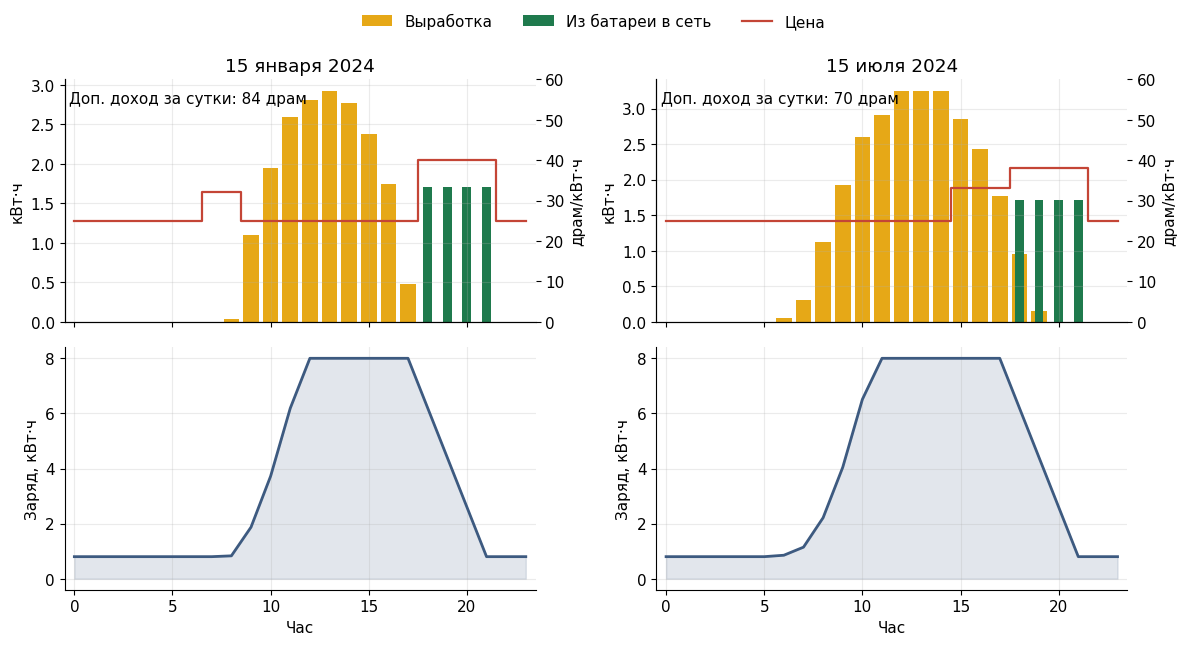

In [3]:
def day_slice(station_id, day):
    start = pd.Timestamp(day)
    end = start + pd.Timedelta(days=1)
    mask = (
        (hourly['station_id'] == station_id)
        & (hourly['timestamp'] >= start)
        & (hourly['timestamp'] < end)
    )
    return hourly.loc[mask].sort_values('timestamp').copy()


def plot_day(ax_energy, ax_soc, frame, title):
    hours = frame['timestamp'].dt.hour
    ax_energy.bar(hours, frame['pv_energy_kwh'], color='#e6a817', width=0.8, label='Выработка')
    ax_energy.bar(
        hours,
        frame['battery_to_grid_kwh'],
        color='#1f7a4d',
        width=0.45,
        label='Из батареи в сеть',
    )
    ax_price = ax_energy.twinx()
    ax_price.step(hours, frame['price_amd_per_kwh'], where='mid', color='#c44536', linewidth=1.6, label='Цена')
    ax_price.set_ylim(0, 60)
    ax_price.grid(False)
    ax_price.set_ylabel('драм/кВт·ч')
    ax_energy.set_xlim(-0.5, 23.5)
    ax_energy.set_ylabel('кВт·ч')
    ax_energy.set_title(title)
    extra = frame['revenue_amd'].sum() - frame['revenue_if_immediate_amd'].sum()
    ax_energy.text(
        0.01,
        0.95,
        f'Доп. доход за сутки: {extra:.0f} драм',
        transform=ax_energy.transAxes,
        va='top',
    )

    ax_soc.plot(hours, frame['soc_kwh'], color='#3d5a80', linewidth=2)
    ax_soc.fill_between(hours, frame['soc_kwh'], color='#3d5a80', alpha=0.15)
    ax_soc.set_xlim(-0.5, 23.5)
    ax_soc.set_xlabel('Час')
    ax_soc.set_ylabel('Заряд, кВт·ч')
    return ax_energy, ax_price


fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), sharex='col')
winter = day_slice('YE-01', '2024-01-15')
summer = day_slice('YE-01', '2024-07-15')
energy_axes = []
price_axes = []
for column, frame, title in (
    (0, winter, '15 января 2024'),
    (1, summer, '15 июля 2024'),
):
    energy, price = plot_day(axes[0, column], axes[1, column], frame, title)
    energy_axes.append(energy)
    price_axes.append(price)

handles, labels = energy_axes[0].get_legend_handles_labels()
price_handles, price_labels = price_axes[0].get_legend_handles_labels()
fig.legend(handles + price_handles, labels + price_labels, loc='upper center', ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## 4. Выработка, перенос в дорогие часы и доход

Годовая выработка считается за 2024 год на 1 кВт панели. Перенос — это киловатт-часы, проданные по повышенной цене сверх того, что станция выработала прямо в эти часы. Доп. доход — разница с продажей каждого киловатт-часа в час выработки. Перенос и доход на графиках тоже на 1 кВт панели, чтобы регионы с разным размером станций сравнивались друг с другом.

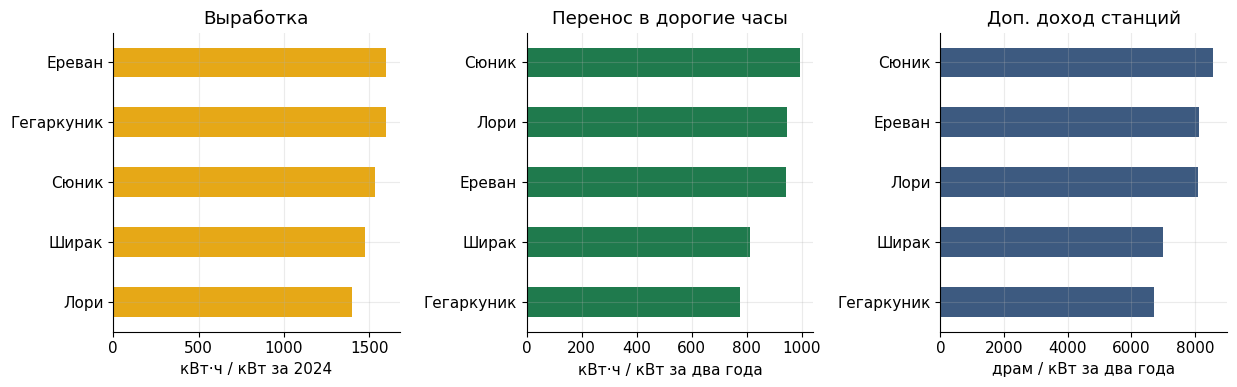

Выработано за два года: 552.5 МВт·ч
Продано в сеть: 535.0 МВт·ч
Перенесено в часы повышенной цены: 161.9 МВт·ч
Доп. доход: 1,392,670 драм (9.9% к продаже сразу)


In [4]:
year_2024 = hourly[hourly['timestamp'].dt.year == 2024]
produced = year_2024.groupby('station_id')['pv_energy_kwh'].sum()
capacity = stations.set_index('station_id')['pv_kw']
region_name = stations.set_index('station_id')['region_name']
specific = (produced / capacity).rename('kwh_per_kw')
specific = specific.to_frame().join(region_name)
yield_by_region = specific.groupby('region_name')['kwh_per_kw'].mean().sort_values()

totals = daily.copy()
totals['shifted_kwh'] = (
    totals['sold_at_increased_price_kwh'] - totals['pv_generated_at_increased_price_kwh']
).clip(lower=0)
totals = totals.merge(stations[['station_id', 'region_name']], on='station_id', how='left')
installed_kw = stations.groupby('region_name')['pv_kw'].sum()
shift_by_region = (totals.groupby('region_name')['shifted_kwh'].sum() / installed_kw).sort_values()
profit_by_region = (totals.groupby('region_name')['extra_profit_amd'].sum() / installed_kw).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4))
yield_by_region.plot.barh(ax=axes[0], color='#e6a817')
axes[0].set_xlabel('кВт·ч / кВт за 2024')
axes[0].set_ylabel('')
axes[0].set_title('Выработка')

shift_by_region.plot.barh(ax=axes[1], color='#1f7a4d')
axes[1].set_xlabel('кВт·ч / кВт за два года')
axes[1].set_ylabel('')
axes[1].set_title('Перенос в дорогие часы')

profit_by_region.plot.barh(ax=axes[2], color='#3d5a80')
axes[2].set_xlabel('драм / кВт за два года')
axes[2].set_ylabel('')
axes[2].set_title('Доп. доход станций')
fig.tight_layout()
plt.show()

total_pv = totals['pv_kwh'].sum()
total_sold = totals['energy_sold_kwh'].sum()
total_shift = totals['shifted_kwh'].sum()
total_extra = totals['extra_profit_amd'].sum()
total_base = totals['revenue_if_immediate_amd'].sum()
print(f'Выработано за два года: {total_pv / 1000:.1f} МВт·ч')
print(f'Продано в сеть: {total_sold / 1000:.1f} МВт·ч')
print(f'Перенесено в часы повышенной цены: {total_shift / 1000:.1f} МВт·ч')
print(f'Доп. доход: {total_extra:,.0f} драм ({100 * total_extra / total_base:.1f}% к продаже сразу)')

## 5. Прогноз выработки

Цель модели — `pv_energy_kwh` на следующий час. Признаки станция знает заранее: календарь, паспорт панели и прогноз погоды региона.

Сравнение на 2025 годе, которого модель не видела:

- наивный профиль: средняя выработка этой станции в тот же месяц и час в 2024 году;
- бустинг по облачности, температуре и паспорту, без прямой радиации;
- тот же бустинг плюс GHI, DNI и DHI.

Прямая радиация почти определяет киловатт-часы, поэтому третья модель — верхняя планка, если прогноз погоды уже содержит облучённость. Вторая нужна, когда из прогноза есть только облачность и температура. В этой синтетике облучённость собрана из облачности, поэтому две модели бустинга близки. Если в модели уже есть GHI, важность облачности падает: радиация её уже содержит.

In [5]:
frame = hourly.merge(weather, on=['region_id', 'timestamp'], how='left')
frame = frame.merge(
    stations[['station_id', 'pv_kw', 'tilt_deg', 'azimuth_deg', 'performance_ratio']],
    on='station_id',
    how='left',
)
frame['hour'] = frame['timestamp'].dt.hour
frame['month'] = frame['timestamp'].dt.month
frame['dayofyear'] = frame['timestamp'].dt.dayofyear

features_cloud = [
    'hour', 'month', 'dayofyear',
    'temp_c', 'cloud_cover',
    'pv_kw', 'tilt_deg', 'azimuth_deg', 'performance_ratio',
]
features_sun = features_cloud + ['ghi_w_m2', 'dni_w_m2', 'dhi_w_m2']
target = 'pv_energy_kwh'

missing = frame[features_sun + [target]].isna().sum().sum()
if missing:
    raise ValueError(f'В признаках есть пропуски: {missing}')

train = frame[frame['timestamp'] < '2025-01-01'].copy()
test = frame[frame['timestamp'] >= '2025-01-01'].copy()
print(f'Обучение: {len(train):,} часов'.replace(',', ' '))
print(f'Проверка: {len(test):,} часов'.replace(',', ' '))

profile = (
    train.groupby(['station_id', 'month', 'hour'])[target]
    .mean()
    .rename('pred_profile')
)
test = test.merge(profile, on=['station_id', 'month', 'hour'], how='left')
test['pred_profile'] = test['pred_profile'].fillna(0)


def fit_booster(columns):
    model = HistGradientBoostingRegressor(
        learning_rate=0.08,
        max_iter=160,
        max_depth=8,
        min_samples_leaf=40,
        l2_regularization=0.1,
        early_stopping=False,
        random_state=42,
    )
    model.fit(train[columns], train[target])
    prediction = np.clip(model.predict(test[columns]), 0, None)
    return model, prediction


model_cloud, pred_cloud = fit_booster(features_cloud)
model_sun, pred_sun = fit_booster(features_sun)
test['pred_cloud'] = pred_cloud
test['pred_sun'] = pred_sun


def score_block(y_true, y_pred):
    daylight = test['hour'].between(7, 18)
    return {
        'MAE, все часы': mean_absolute_error(y_true, y_pred),
        'MAE, 7–18': mean_absolute_error(y_true[daylight], y_pred[daylight]),
        'RMSE, 7–18': mean_squared_error(y_true[daylight], y_pred[daylight], squared=False),
    }


scores = pd.DataFrame({
    'Профиль месяц-час': score_block(test[target], test['pred_profile']),
    'Бустинг, облачность': score_block(test[target], test['pred_cloud']),
    'Бустинг, радиация': score_block(test[target], test['pred_sun']),
}).T
scores = scores.round(3)
display(scores)

naive = scores.loc['Профиль месяц-час', 'MAE, 7–18']
best = scores.loc['Бустинг, радиация', 'MAE, 7–18']
print(f'Радиационная модель снижает дневную MAE на {100 * (naive - best) / naive:.0f}% относительно профиля.')

Обучение: 263 520 часов
Проверка: 262 800 часов


,"MAE, все часы","MAE, 7–18","RMSE, 7–18"
Профиль месяц-час,0.116,0.230,0.434
"Бустинг, облачность",0.051,0.097,0.258
"Бустинг, радиация",0.045,0.088,0.253


Радиационная модель снижает дневную MAE на 62% относительно профиля.


Ниже — неделя июля 2025 на `YE-01` и важные признаки радиационной модели. Важность считалась перестановкой на случайных 8 000 часах проверки: насколько вырастает MAE, если признак перемешать.

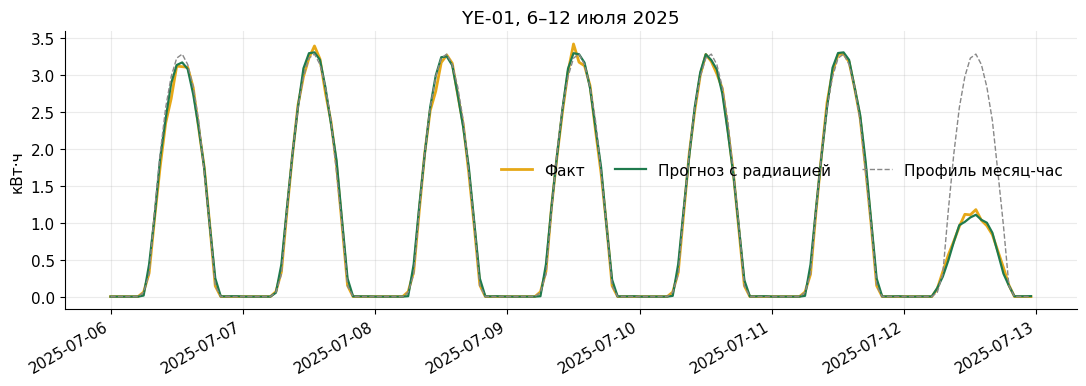

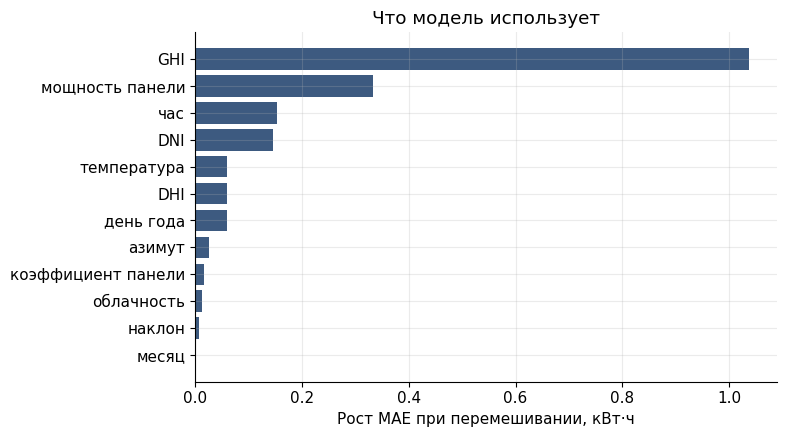

In [6]:
sample = test[(test['station_id'] == 'YE-01') & (test['timestamp'] >= '2025-07-06') & (test['timestamp'] < '2025-07-13')]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sample['timestamp'], sample[target], color='#e6a817', linewidth=2, label='Факт')
ax.plot(sample['timestamp'], sample['pred_sun'], color='#1f7a4d', linewidth=1.6, label='Прогноз с радиацией')
ax.plot(sample['timestamp'], sample['pred_profile'], color='#888888', linewidth=1, linestyle='--', label='Профиль месяц-час')
ax.set_ylabel('кВт·ч')
ax.set_title('YE-01, 6–12 июля 2025')
ax.legend(frameon=False, ncol=3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

rng = np.random.default_rng(42)
take = rng.choice(len(test), size=8000, replace=False)
probe = test.iloc[take]
importance = permutation_importance(
    model_sun,
    probe[features_sun],
    probe[target],
    n_repeats=4,
    random_state=42,
    scoring='neg_mean_absolute_error',
)
order = np.argsort(importance.importances_mean)
labels = {
    'hour': 'час',
    'month': 'месяц',
    'dayofyear': 'день года',
    'temp_c': 'температура',
    'cloud_cover': 'облачность',
    'pv_kw': 'мощность панели',
    'tilt_deg': 'наклон',
    'azimuth_deg': 'азимут',
    'performance_ratio': 'коэффициент панели',
    'ghi_w_m2': 'GHI',
    'dni_w_m2': 'DNI',
    'dhi_w_m2': 'DHI',
}
names = [labels[features_sun[i]] for i in order]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(names, importance.importances_mean[order], color='#3d5a80')
ax.set_xlabel('Рост MAE при перемешивании, кВт·ч')
ax.set_title('Что модель использует')
fig.tight_layout()
plt.show()

## 6. Прогноз перед вечерней продажей

Утром биржа складывает прогноз выработки с 8:00 до 16:00. Это оценка того, сколько энергии станция успеет накопить к вечерней цене. На графике — `YE-01` летом 2025: предсказанная дневная выработка и фактическая отдача батареи в 18:00–21:00. Летом батарея 8 кВт·ч заполняется даже в пасмурный день, поэтому вечерняя отдача почти ровная, а прогноз виден на провалах дневной выработки.

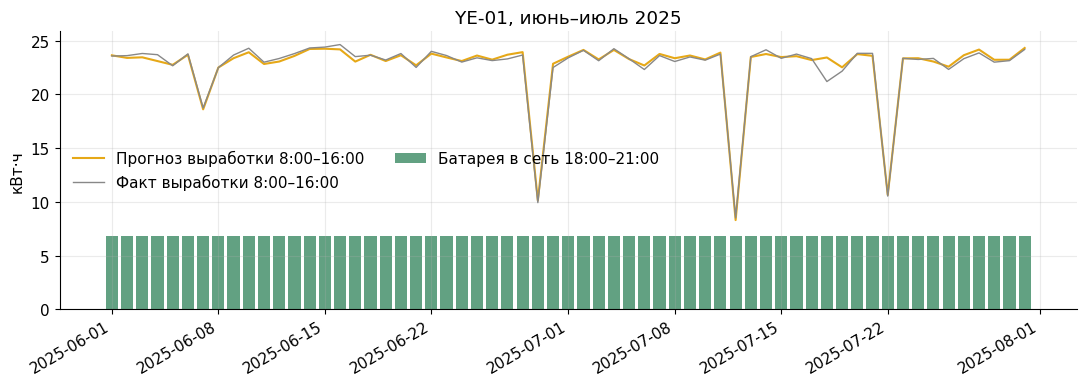

MAE дневной суммы 8:00–16:00 по всем станциям 2025 года: 0.51 кВт·ч
Средняя дневная выработка в этом окне: 23.4 кВт·ч
Средняя вечерняя отдача батареи: 7.44 кВт·ч


In [7]:
evening_price = test['price_amd_per_kwh'] > 25
daytime = test[test['hour'].between(8, 16)].copy()
daytime['date'] = daytime['timestamp'].dt.date
evening = test[test['hour'].between(18, 21) & evening_price].copy()
evening['date'] = evening['timestamp'].dt.date

day_sum = daytime.groupby(['station_id', 'date'], as_index=False).agg(
    pred_day_kwh=('pred_sun', 'sum'),
    actual_day_kwh=(target, 'sum'),
)
evening_sum = evening.groupby(['station_id', 'date'], as_index=False).agg(
    battery_evening_kwh=('battery_to_grid_kwh', 'sum'),
)
linked = day_sum.merge(evening_sum, on=['station_id', 'date'], how='left')
linked['battery_evening_kwh'] = linked['battery_evening_kwh'].fillna(0)

one = linked[(linked['station_id'] == 'YE-01') & (pd.to_datetime(linked['date']) >= '2025-06-01') & (pd.to_datetime(linked['date']) < '2025-08-01')]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(pd.to_datetime(one['date']), one['pred_day_kwh'], color='#e6a817', label='Прогноз выработки 8:00–16:00')
ax.plot(pd.to_datetime(one['date']), one['actual_day_kwh'], color='#888888', linewidth=1, label='Факт выработки 8:00–16:00')
ax.bar(pd.to_datetime(one['date']), one['battery_evening_kwh'], color='#1f7a4d', alpha=0.7, label='Батарея в сеть 18:00–21:00')
ax.set_ylabel('кВт·ч')
ax.set_title('YE-01, июнь–июль 2025')
ax.legend(frameon=False, ncol=2)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

day_mae = mean_absolute_error(linked['actual_day_kwh'], linked['pred_day_kwh'])
print(f'MAE дневной суммы 8:00–16:00 по всем станциям 2025 года: {day_mae:.2f} кВт·ч')
print(f'Средняя дневная выработка в этом окне: {linked["actual_day_kwh"].mean():.1f} кВт·ч')
print(f'Средняя вечерняя отдача батареи: {linked["battery_evening_kwh"].mean():.2f} кВт·ч')

## Что из этого следует

Прогноз выработки нужен до решения реле: днём видно, заполнится ли батарея к опубликованному вечеру. Саму цену модель не выдумывает — её публикует покупатель. Доп. доход станций и киловатт-часы, пришедшие в дорогие часы из батареи, уже лежат в `station_daily.csv` и не требуют отдельной модели.